## Στόχος του προβλήματος

* Αντιμετωπίζουμε ένα **πρόβλημα παλινδρόμησης (regression)**.
* Θέλουμε να προσεγγίσουμε μια άγνωστη συνάρτηση: y ~ sin(x)
  από **θορυβώδη δεδομένα**.
* Ο στόχος δεν είναι η τέλεια προσαρμογή, αλλά η **γενίκευση**.

---

## Δημιουργία δεδομένων

* Τα δεδομένα εισόδου είναι **μονοδιάστατα**: (x from [-10, 10]).
* Οι στόχοι παράγονται ως: y = sin(x) + θόρυβος
* Ο θόρυβος προσομοιώνει **πραγματικά δεδομένα**.
* Χωρίζουμε τα δεδομένα σε **training** και **test set**.

---

## Αρχιτεκτονική του μοντέλου

* Χρησιμοποιούμε ένα **πολυεπίπεδο νευρωνικό δίκτυο (MLP)**.
* Δομή:

  * Είσοδος: 1 χαρακτηριστικό
  * 2 κρυφά επίπεδα με **62 νευρώνες** το καθένα
  * Ενεργοποίηση **ReLU**
  * Έξοδος: 1 νευρώνας με γραμμική ενεργοποίηση
* Το βάθος αυξάνει τη **δυναμικότητα** του μοντέλου.

---

## Ερμηνεία του μοντέλου

* Το μοντέλο υπολογίζει: f(x) = W_3 sigma(W_2*sigma(W_1 x))
* Οι ReLU δημιουργούν **κομμάτι-γραμμικές (piecewise linear)** συναρτήσεις.
* Σε 1D, το δίκτυο λειτουργεί σαν **γραμμικό spline**.

---

## Εκπαίδευση

* Συνάρτηση κόστους: **Mean Squared Error (MSE)**.
* Βελτιστοποιητής: **Adam**.
* Εκπαίδευση με **ολόκληρο το σύνολο δεδομένων εκπαίδευσης** (full-batch).
* Σε κάθε εποχή:

  * forward pass
  * υπολογισμός loss
  * backpropagation
  * ενημέρωση βαρών

---

## Εξέλιξη της προσαρμογής

* Παρατηρούμε την καμπύλη που μαθαίνει το μοντέλο στις επαναλήψεις:

  * 10, 50, 100, 200, 300, 400, 500, 1000
* Στις αρχικές επαναλήψεις:

  * το μοντέλο είναι **υπο-προσαρμοσμένο (underfitting)**
* Με περισσότερη εκπαίδευση:

  * μαθαίνει το γενικό σχήμα
  * βελτιώνει τις λεπτομέρειες

---

## Καμπύλη απώλειας (loss curve)

* Η καμπύλη loss δείχνει τη **δυναμική της εκπαίδευσης**.
* Απότομη πτώση στην αρχή → μάθηση χαμηλών συχνοτήτων.
* Αργή μείωση αργότερα → λεπτομερής προσαρμογή.
* Το loss δεν μηδενίζεται λόγω **θορύβου**.

---

## Αξιολόγηση & γενίκευση

* Η τελική αξιολόγηση γίνεται στο **test set**.
* Το MSE μετράει τη **γενίκευση** του μοντέλου.
* Καλή προσαρμογή ≠ τέλεια πρόβλεψη.
---

In [23]:
# -----------------------------
# Imports
# -----------------------------

import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


from sklearn.metrics import mean_squared_error

In [24]:
# # -----------------------------
# # Generate full dataset
# # -----------------------------

X_train = np.array(np.linspace(-10, 10, 1000))
y_train = np.sin(X_train) + np.random.normal(0, 0.2, size=X_train.shape)
X_test = np.linspace(-10, 10, 500)
y_test = np.sin(X_test) + np.random.normal(0, 0.2, size=X_test.shape)

# Convert to PyTorch tensors (shape: N x 1)
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [25]:
# -----------------------------
# Define the neural network
# -----------------------------

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 62),
            nn.ReLU(),
            nn.Linear(62, 62),
            nn.ReLU(),
            nn.Linear(62, 1)
        )

    def forward(self, x):
        return self.net(x)


model = MLP()

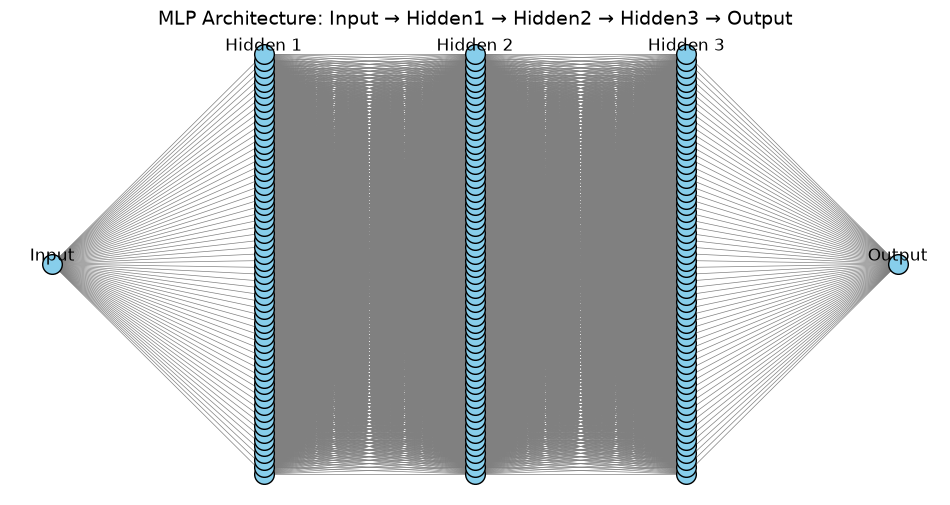

In [26]:
# -----------------------------
# Plot model architecture
# -----------------------------

layers = [1, 62, 62, 62, 1]  # Input, hidden1, hidden2, hidden3, output

fig, ax = plt.subplots(figsize=(12, 6))

# Χώρος μεταξύ των νευρώνων
v_spacing = 1
h_spacing = 2

# Για κάθε layer
for i, n_neurons in enumerate(layers):
    # Υπολογισμός θέσεων y για κάθε νευρώνα
    y_positions = np.linspace(-(n_neurons-1)/2, (n_neurons-1)/2, n_neurons) * v_spacing
    x_positions = np.ones(n_neurons) * i * h_spacing

    # Σχεδίαση νευρώνων
    ax.scatter(x_positions, y_positions, s=200, color='skyblue', edgecolors='k', zorder=3)

    # Ετικέτες για input και output
    if i == 0:
        ax.text(i*h_spacing, max(y_positions)+0.5, "Input", ha='center', fontsize=12)
    elif i == len(layers)-1:
        ax.text(i*h_spacing, max(y_positions)+0.5, "Output", ha='center', fontsize=12)
    else:
        ax.text(i*h_spacing, max(y_positions)+0.5, f"Hidden {i}", ha='center', fontsize=12)

# Σχεδίαση συνδέσεων μεταξύ νευρώνων
for i in range(len(layers)-1):
    n1 = layers[i]
    n2 = layers[i+1]
    y1 = np.linspace(-(n1-1)/2, (n1-1)/2, n1) * v_spacing
    y2 = np.linspace(-(n2-1)/2, (n2-1)/2, n2) * v_spacing
    x1 = i * h_spacing
    x2 = (i+1) * h_spacing
    for y_start in y1:
        for y_end in y2:
            ax.plot([x1, x2], [y_start, y_end], 'gray', linewidth=0.5, zorder=1)

ax.axis('off')
ax.set_title("MLP Architecture: Input → Hidden1 → Hidden2 → Hidden3 → Output", fontsize=14)
plt.show()

In [27]:
# -----------------------------
# Loss function and optimizer
# -----------------------------

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

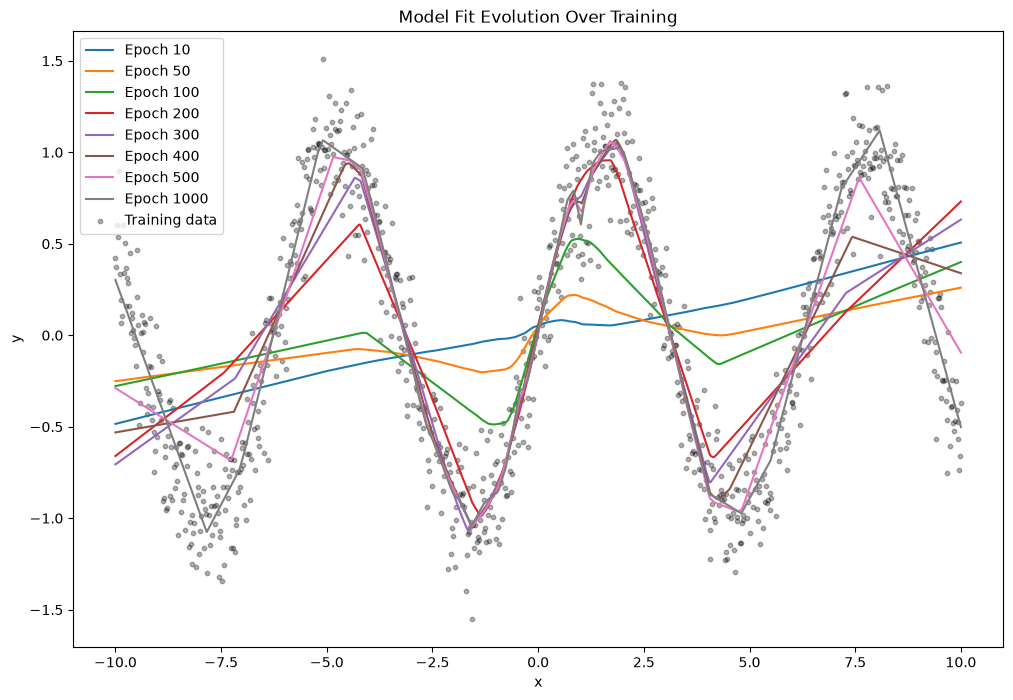

In [28]:
# -----------------------------
# Training loop with checkpoints
# -----------------------------

checkpoints = [10, 50, 100, 200, 300, 400, 500, 1000]
current_epoch = 0

loss_history = []

plt.figure(figsize=(12, 8))

for target_epoch in checkpoints:
    for epoch in range(current_epoch, target_epoch):
        model.train()

        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()

        # Record loss
        loss_history.append(loss.item())

    current_epoch = target_epoch

    # Evaluate model at checkpoint
    model.eval()
    with torch.no_grad():
        y_pred = model(X_train_t).numpy()

    # Plot fitted curve
    plt.plot(
        X_train,
        y_pred,
        label=f"Epoch {target_epoch}"
    )

# Plot training data
plt.scatter(
    X_train,
    y_train,
    color="black",
    s=10,
    alpha=0.3,
    label="Training data"
)

plt.title("Model Fit Evolution Over Training")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

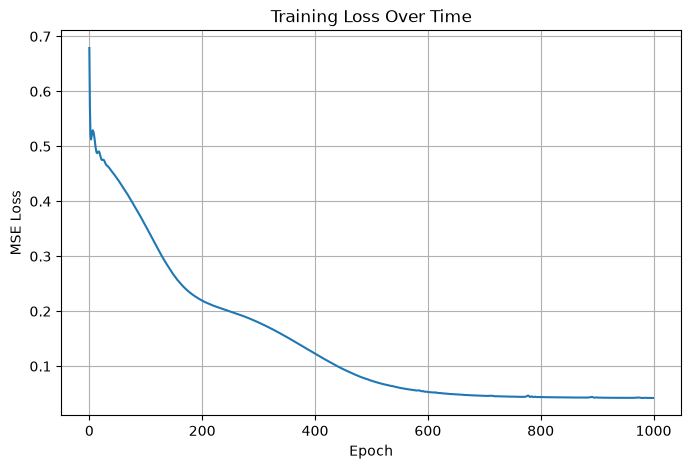

In [29]:
# -----------------------------
# Plot training loss over time
# -----------------------------

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Over Time")
plt.grid(True)
plt.show()

In [30]:
# -----------------------------
# Final evaluation on test data
# -----------------------------

model.eval()
with torch.no_grad():
    test_pred = model(X_test_t).numpy()

mse = mean_squared_error(y_test, test_pred)
print("Final Test MSE:", mse)

Final Test MSE: 0.04249942445240441


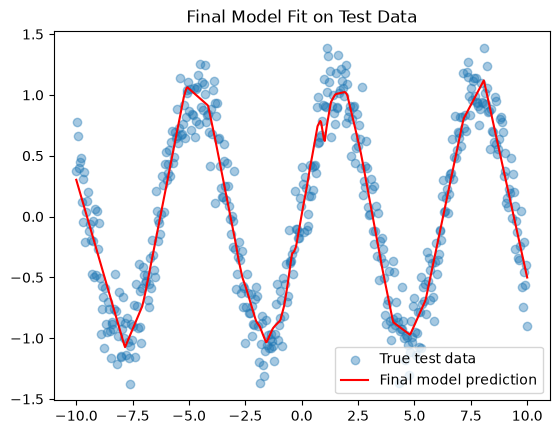

In [31]:
# -----------------------------
# Plot final test fit
# -----------------------------

plt.scatter(X_test, y_test, label="True test data", alpha=0.4)
plt.plot(X_test, test_pred, color="red", label="Final model prediction")
plt.legend()
plt.title("Final Model Fit on Test Data")
plt.show()